<a href="https://colab.research.google.com/github/stellasdong/676_project/blob/main/checkpoint2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Research Question Formation

**Author:** Stella Dong

*Department of Computer Science & Engineering, Texas A&M University*  
*This work was completed as part of CSCE 676: Data Mining and Analysis, taught by Prof. James Caverlee.*

The Github repository of this project can be found here: [Github link](https://github.com/stellasdong/676_project/).

---


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
path = "/content/drive/MyDrive/TAMU/data_mining/project_data"
os.chdir(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from itertools import combinations

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


!pip install icd-mappings
from icdmappings import Mapper

In [ ]:
bcs_tx_inpatient = pd.read_csv("bcs_tx_inpatient.csv")

/tmp/ipykernel_84114/1439007442.py:1: DtypeWarning: Columns (5,7,82,89,90,91,92,145,147,149,151) have mixed types. Specify dtype option on import or set low_memory=False.
  bcs_tx_inpatient = pd.read_csv("bcs_tx_inpatient.csv")


## Project Scope
### Dataset: [Texas Inpatient PUF](https://www.dshs.texas.gov/center-health-statistics/texas-health-care-information-collection/download-and-purchase-data/texas-inpatient-public-use-data-file-pudf/public-use-data-File-pudf-inpatient-free-download)

The dataset that I am working with is the Texas Inpatient Dataset, filtered to include 6 facilities in the Bryan-College Station are, over the entire duration of 2019. The techniques that I initially found could be explored through this dataset are frequent itemsets (course), clustering (course) and sequence analysis (external).

## Research Questions
RQ1: Do distinct patient clusters based on diagnosis patterns reveal any patterns with patient demographics?
* Data Mining Task: Clustering
* Relevant algorithms: k-means clustering (course), hierarchical clustering (course), PCA or t-SNE for dimentionality reduction (course), sparse clustering (external)
* Evaluation Criteria: silhouette score, elbow method, cluster interpretability

RQ2: How do frequent diagnosis patterns and optimal support thresholds differ across diagnosis code granularities?
* Data Mining Task: Frequent itemsets/association rules
* Relevant algorithms: apriori (course)
* Evaluation criteria: support, confidence, lift, number of patterns and pattern distribution, interpretability

RQ3: What sequential patterns exist in diagnosis ordering within single admissions?
* Data Mining Task: Sequence mining analysis
* Relevant algoriths: Prefixspan (external), Generalized Sequential Patterns (external)
* Evaluation criteria: support, confidence, pattern length, coverage, temporal coherence

### Research Question to Method Mapping Table

| Research Question | Method | Course vs External |
| :---: | :--- | :---: |
| 1 | k-means clustering | Course |
| 1 | Hierarchical clustering | Course |
| 1 | PCA/t-SNE for dimentionality reduction | Course |
| 1 | Sparse clustering | External |
| 2 | Apriori | Course |
| 3 | Prefixspan | External |
| 3 | Generalized sequential patterns | External |

## Motivation and Feasibility

### Research Question 1
Motivation: The EDA from checkpoint 1 shows diverse diagnosis combinations with varying complexity. By using the CCSR mapping, we can explore how the body system distribution reveals multi-system involvement patterns.

Non-triviality: This dataset has high-dimensional sparse data, with thousands of unique diagnoses codes. Also, there is a need to balance clinical interpretability with statistical validity, as it would be nearly impossible to interpret any clusters with those thousands of diagnoses codes.

Feasibility: The high dimensionality mentioned in the previous section means I needed to come up with ways to reduce this. The first is to use CCSR mappings, which reduced the thousands of diagnosis codes to a few hundred. This will likely not be sufficient, so we will use dimensionality reduction via PCA/t-SNE or sparse clustering.

Risks: Like previously mentioned, the curse of dimensionality. Also, there is the risk of the high computational cost for large datasets, but ideally we will be able to sample to dataset or run the dataset in batches.

In [ ]:
# Test if ICD 10 mapping to CCSR maps all ICD 10 codes
mapper = Mapper()

df = bcs_tx_inpatient.copy()

def collect_all_diagnoses(df):
  all_codes = set()

  all_codes.update(df['PRINC_DIAG_CODE'].dropna().unique())
  for i in range(1, 25):
      col = f'OTH_DIAG_CODE_{i}'
      if col in df.columns:
          all_codes.update(df[col].dropna().unique())

  return list(all_codes)

all_icd_codes = collect_all_diagnoses(df)
print(f"Total unique ICD-10 codes: {len(all_icd_codes)}")
print(f"Sample codes: {all_icd_codes[:10]}")

def map_to_cssr(codes, batch_size=5571):
  mapping_dict = {}
  for i in range(0, len(codes), batch_size):
    batch = codes[i:i+batch_size]
    results = mapper.map(batch, source='icd10', target='ccsr')
    for code, ccsr in zip(batch, results):
        mapping_dict[code] = ccsr

    return mapping_dict

ccsr_mapping = map_to_cssr(all_icd_codes)

mapped_count = sum(1 for v in ccsr_mapping.values() if v is not None)
coverage = mapped_count / len(ccsr_mapping) * 100
print(f"Mapped: {mapped_count:,} / {len(ccsr_mapping):,} codes")

# Identify unmapped codes
unmapped_codes = [code for code, ccsr in ccsr_mapping.items() if ccsr is None]
print(f"\nUnmapped codes: {len(unmapped_codes)}")

if unmapped_codes:
    print("\nSample unmapped codes:")
    print(unmapped_codes[:20])


Total unique ICD-10 codes: 5571
Sample codes: ['F1211', 'R209', 'S20222A', 'O99343', 'A4101', 'L500', 'L89311', 'E83111', 'I6381', 'I4519']
Mapped: 5,571 / 5,571 codes

Unmapped codes: 0



1. FEATURE SPACE DIMENSIONALITY:
  Full ICD-10         : 1593 unique values
  3-digit ICD         :  513 unique values
  CCSR Category       :  308 unique values
  CCSR System         :   22 unique values

2. SPARSITY ANALYSIS (Top 200 CCSR, n=10000):
  Matrix shape: (10000, 200)
  Sparsity: 96.6%
  Avg diagnoses per patient: 6.87
  Coverage: 100.0% patients have ≥1 diagnosis


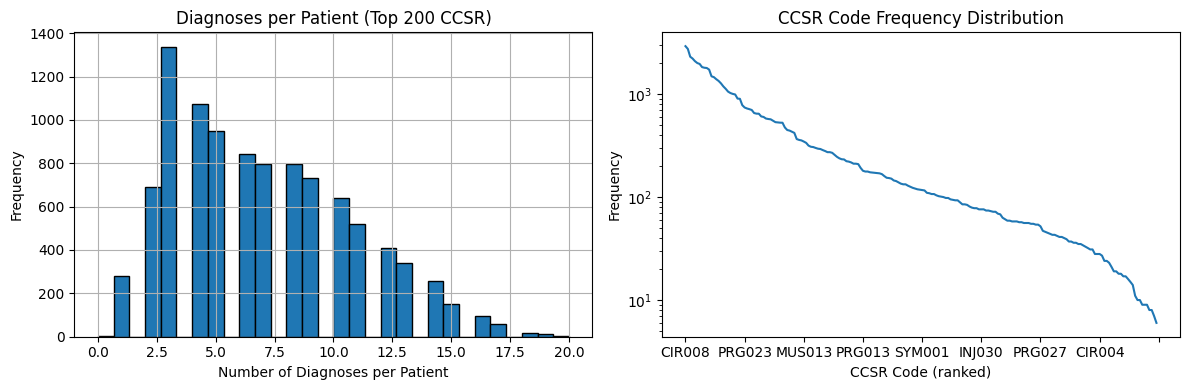

In [ ]:
# Apply mapping to dataframe
df['PRINC_CCSR'] = df['PRINC_DIAG_CODE'].map(ccsr_mapping)
for i in range(1, 25):
    diag_col = f'OTH_DIAG_CODE_{i}'
    if diag_col in df.columns:
        df[f'OTH_CCSR_{i}'] = df[diag_col].map(ccsr_mapping)

# Create derived features
df['CCSR_SYSTEM'] = df['PRINC_CCSR'].str[:3]
df['NUM_DIAGNOSES'] = df[[f'OTH_CCSR_{i}' for i in range(1, 25)]].notna().sum(axis=1) + 1

# Examine feature space at different granularities
granularity_analysis = {
    'Full ICD-10': df['PRINC_DIAG_CODE'].nunique(),
    '3-digit ICD': df['PRINC_DIAG_CODE'].str[:3].nunique(),
    'CCSR Category': df['PRINC_CCSR'].nunique(),
    'CCSR System': df['CCSR_SYSTEM'].nunique()
}

print("\n1. FEATURE SPACE DIMENSIONALITY:")
for level, count in granularity_analysis.items():
    print(f"  {level:20s}: {count:4d} unique values")

# Test sparsity with top 200 CCSR codes
top_200_ccsr = df['PRINC_CCSR'].value_counts().head(200).index

# Create binary matrix for sample
sample_size = min(10000, len(df))
sample_df = df.sample(n=sample_size, random_state=42)

# Build feature matrix
feature_matrix = pd.DataFrame(0, index=sample_df.index, columns=top_200_ccsr)

for idx, row in sample_df.iterrows():
    # Principal diagnosis
    if row['PRINC_CCSR'] in top_200_ccsr:
        feature_matrix.loc[idx, row['PRINC_CCSR']] = 1

    # Secondary diagnoses
    for i in range(1, 25):
        ccsr_col = f'OTH_CCSR_{i}'
        if ccsr_col in sample_df.columns and pd.notna(row[ccsr_col]):
            if row[ccsr_col] in top_200_ccsr:
                feature_matrix.loc[idx, row[ccsr_col]] = 1

sparsity = 1 - (feature_matrix.sum().sum() / (feature_matrix.shape[0] * feature_matrix.shape[1]))

print(f"\n2. SPARSITY ANALYSIS (Top 200 CCSR, n={sample_size}):")
print(f"  Matrix shape: {feature_matrix.shape}")
print(f"  Sparsity: {sparsity*100:.1f}%")
print(f"  Avg diagnoses per patient: {feature_matrix.sum(axis=1).mean():.2f}")
print(f"  Coverage: {(feature_matrix.sum(axis=1) > 0).mean()*100:.1f}% patients have ≥1 diagnosis")

# Visualize sparsity
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
feature_matrix.sum(axis=1).hist(bins=30, edgecolor='black')
plt.xlabel('Number of Diagnoses per Patient')
plt.ylabel('Frequency')
plt.title('Diagnoses per Patient (Top 200 CCSR)')

plt.subplot(1, 2, 2)
feature_matrix.sum(axis=0).sort_values(ascending=False).plot(kind='line')
plt.xlabel('CCSR Code (ranked)')
plt.ylabel('Frequency')
plt.title('CCSR Code Frequency Distribution')
plt.yscale('log')

plt.tight_layout()
plt.savefig('rq1_eda1_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()


### Research Question 2

Motivation:
We know that the diagnosis codes exist at multiple hierarchical levels (ICD-10-CM, 3-digit, CCSR) and each of these different granularities capture different clinical insights, like identifying very general or very specific patterns in the frequent itemsets.

Non-triviality:
The optimal support threshold varies by granularity level, so I would need to do many tests to find a subjective optimal threshold.

Feasibility:
Apriori algorithm handles transaction-based data well. If the samples are a doable size, then multiple runs at different granularities and support levels should be feasibility. Comparative analysis is straightforward and by using lift and confidence metrics, the interpretability should not be a challenge.

Risks:
There is the risk of too many patterns at low support and too few patterns at high support, but this may be mitigated by testing various support levels. Pattern interpretation requires clinical validation and category descriptions, which is time consuming, but a mapping of codes is available.



TRANSACTION STRUCTURE (n=11174):

CCSR Category:
  Transactions: 11,174
  Unique items: 439
  Avg transaction size: 10.27
  Range: [1, 25]

3-digit ICD:
  Transactions: 11,174
  Unique items: 1,129
  Avg transaction size: 11.20
  Range: [1, 25]

CCSR System:
  Transactions: 11,174
  Unique items: 22
  Avg transaction size: 5.72
  Range: [1, 14]



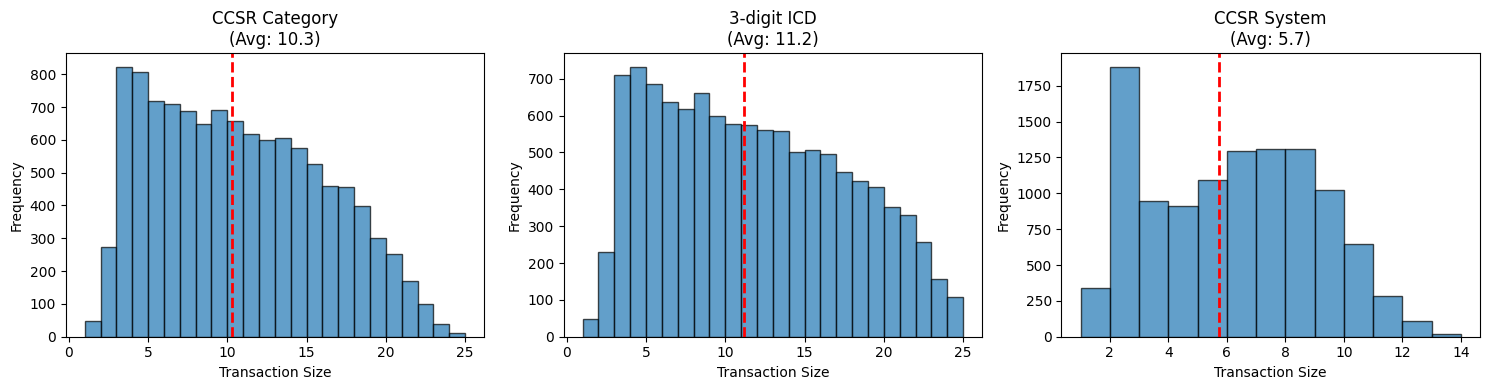

In [ ]:
# Create transactions at different granularities
def create_transactions(df, level='ccsr', sample_n=None):
    if sample_n:
        df = df.sample(n=min(sample_n, len(df)), random_state=42)

    transactions = []

    if level == 'ccsr':
        cols = ['PRINC_CCSR'] + [f'OTH_CCSR_{i}' for i in range(1, 25)]
    elif level == '3digit':
        cols = ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]
    elif level == 'system':
        # Will extract first 3 chars from CCSR
        cols = ['PRINC_CCSR'] + [f'OTH_CCSR_{i}' for i in range(1, 25)]

    for idx, row in df.iterrows():
        transaction = []
        for col in cols:
            if col in df.columns and pd.notna(row[col]):
                if level == '3digit' and 'DIAG' in col:
                    transaction.append(str(row[col])[:3])
                elif level == 'system' and 'CCSR' in col:
                    transaction.append(str(row[col])[:3])
                else:
                    transaction.append(row[col])

        # Remove duplicates
        transaction = list(dict.fromkeys(transaction))
        if len(transaction) > 0:
            transactions.append(transaction)

    return transactions

# Create transactions at multiple levels
sample_size = min(50000, len(df))
print(f"\nTRANSACTION STRUCTURE (n={sample_size}):\n")

levels = {
    'CCSR Category': create_transactions(df, level='ccsr', sample_n=sample_size),
    '3-digit ICD': create_transactions(df, level='3digit', sample_n=sample_size),
    'CCSR System': create_transactions(df, level='system', sample_n=sample_size)
}

for level_name, trans in levels.items():
    unique_items = set([item for t in trans for item in t])
    avg_size = np.mean([len(t) for t in trans])

    print(f"{level_name}:")
    print(f"  Transactions: {len(trans):,}")
    print(f"  Unique items: {len(unique_items):,}")
    print(f"  Avg transaction size: {avg_size:.2f}")
    print(f"  Range: [{min(len(t) for t in trans)}, {max(len(t) for t in trans)}]")
    print()

# Visualize transaction sizes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (level_name, trans) in enumerate(levels.items()):
    sizes = [len(t) for t in trans]
    axes[idx].hist(sizes, bins=range(1, max(sizes)+1), edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel('Transaction Size')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{level_name}\n(Avg: {np.mean(sizes):.1f})')
    axes[idx].axvline(np.mean(sizes), color='r', linestyle='--', linewidth=2)

plt.tight_layout()
plt.savefig('rq2_eda1_transactions.png', dpi=150, bbox_inches='tight')
plt.show()

### Research Question 3

Motivation:
The dataset shows variable number of diagnoses per patient up to 26 diagnoses codes. We assume that the ordering of diagnoses within a single admission may reflect clinical progression, from the inital diagnosis upon admission to any further diagnoses after further testing. Finding sequence patterns can reveal common complication pathways amongst these patients.

Non-triviality:
Standard frequent itemset mining ignores order, so we need specialized sequence mining algorithms. This question works entirely under the assumption that the diagnosis order is true to the discovery of ailments in a single patient visit.

Feasibility:
There are plenty of algorithms available to run sequence mining, and because of the indexing of each column, we can construct a sequence from the diagnosis position order.

Risks:
The diagnosis order may not reflect true temporal sequence and there are no timestamps available to validate temporal ordering, so patterns may be dominated by documentation practices rather than clinical events. Also, there is a higher computational cost for longer sequences.




CCSR Sequences:
  Total sequences: 11128
  Avg length: 12.62
  Min length: 2
  Max length: 25


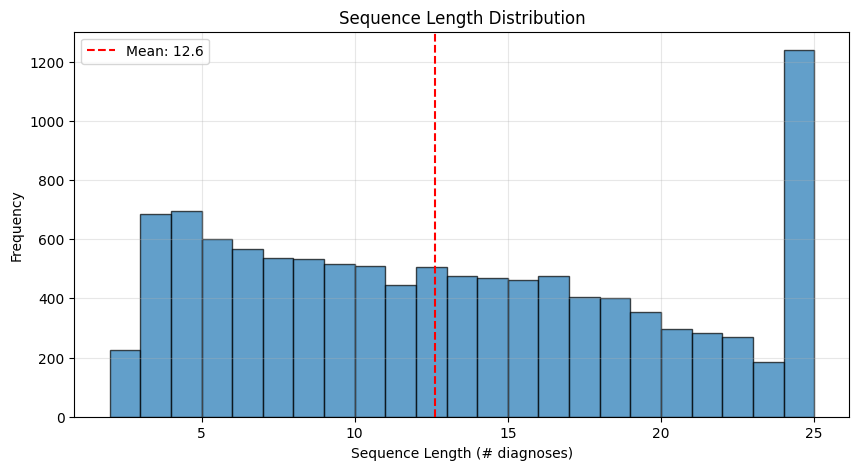


  Sequence length distribution:
    2-3 items: 8.2%
    4-6 items: 16.7%
    7-10 items: 18.8%
    11+ items: 56.3%


In [ ]:
# Create sequences from diagnosis ordering
def create_sequences(df, use_ccsr=True, min_length=2):
    sequences = []

    if use_ccsr:
        cols = ['PRINC_CCSR'] + [f'OTH_CCSR_{i}' for i in range(1, 25)]
    else:
        cols = ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]

    for idx, row in df.iterrows():
        sequence = []
        for col in cols:
            if col in df.columns and pd.notna(row[col]):
                sequence.append(row[col])

        if len(sequence) >= min_length:
            sequences.append(sequence)

    return sequences

# Create sequences at different granularities
sample_df = df.sample(n=min(50000, len(df)))

sequences_ccsr = create_sequences(sample_df, use_ccsr=True, min_length=2)
sequences_3dig = create_sequences(sample_df, use_ccsr=False, min_length=2)

print(f"\nCCSR Sequences:")
print(f"  Total sequences: {len(sequences_ccsr)}")
print(f"  Avg length: {np.mean([len(s) for s in sequences_ccsr]):.2f}")
print(f"  Min length: {min(len(s) for s in sequences_ccsr)}")
print(f"  Max length: {max(len(s) for s in sequences_ccsr)}")

# Sequence length distribution
seq_lengths = [len(s) for s in sequences_ccsr]

plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=range(2, max(seq_lengths)+1), edgecolor='black', alpha=0.7)
plt.xlabel('Sequence Length (# diagnoses)')
plt.ylabel('Frequency')
plt.title('Sequence Length Distribution')
plt.axvline(x=np.mean(seq_lengths), color='r', linestyle='--', label=f'Mean: {np.mean(seq_lengths):.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Length categories
print(f"\n  Sequence length distribution:")
print(f"    2-3 items: {sum(1 for s in seq_lengths if s <= 3)/len(seq_lengths)*100:.1f}%")
print(f"    4-6 items: {sum(1 for s in seq_lengths if 4 <= s <= 6)/len(seq_lengths)*100:.1f}%")
print(f"    7-10 items: {sum(1 for s in seq_lengths if 7 <= s <= 10)/len(seq_lengths)*100:.1f}%")
print(f"    11+ items: {sum(1 for s in seq_lengths if s > 10)/len(seq_lengths)*100:.1f}%")

In [ ]:
position_analysis = {}

for pos in range(1, 11):  # Analyze first 10 positions
    if pos == 1:
        col = 'PRINC_CCSR'
    else:
        col = f'OTH_CCSR_{pos-1}'

    if col in sample_df.columns:
        top_dx = sample_df[col].value_counts().head(5)
        position_analysis[f'Position {pos}'] = top_dx

# Display
for pos, top_dx in list(position_analysis.items())[:5]:
    print(f"\n{pos}:")
    for dx, count in top_dx.items():
        pct = count / len(sample_df) * 100
        print(f"  {dx}: {count} ({pct:.1f}%)")

# Check if patterns shift across positions
for pos in [1, 2, 5, 10]:
    if pos == 1:
        col = 'PRINC_CCSR'
    else:
        col = f'OTH_CCSR_{pos-1}'

    if col in sample_df.columns:
        unique = sample_df[col].nunique()
        filled = sample_df[col].notna().sum()
        print(f"Position {pos}: {unique} unique diagnoses, {filled/len(sample_df)*100:.1f}% filled")


Position 1:
  PNL001: 1507 (13.5%)
  INF002: 855 (7.7%)
  MUS006: 535 (4.8%)
  CIR008: 498 (4.5%)
  FAC010: 294 (2.6%)

Position 2:
  PRG030: 646 (5.8%)
  RSP012: 642 (5.7%)
  CIR019: 517 (4.6%)
  FAC016: 516 (4.6%)
  PNL013: 321 (2.9%)

Position 3:
  FAC016: 530 (4.7%)
  CIR008: 484 (4.3%)
  PRG002: 477 (4.3%)
  PRG030: 377 (3.4%)
  PNL007: 373 (3.3%)

Position 4:
  CIR007: 448 (4.0%)
  CIR008: 447 (4.0%)
  FAC016: 424 (3.8%)
  FAC025: 369 (3.3%)
  END009: 348 (3.1%)

Position 5:
  FAC025: 532 (4.8%)
  CIR008: 384 (3.4%)
  CIR007: 384 (3.4%)
  END009: 375 (3.4%)
  END010: 332 (3.0%)
Position 1: 308 unique diagnoses, 100.0% filled
Position 2: 337 unique diagnoses, 99.6% filled
Position 5: 324 unique diagnoses, 85.2% filled
Position 10: 276 unique diagnoses, 60.6% filled


## Methodological Planning

### Course Algorithms
* K-means clustering (RQ1 - primary clustering method)
* Hierarchical clustering (RQ1 - agglomerative with Ward linkage, dendrogram interpretation)
* PCA (RQ1 - dimensionality reduction and visualization)
* Apriori (RQ2 - primary frequent itemset mining)
* t-SNE (RQ1 - optional 2D cluster visualization)

### External Algorithms
* Sparse Clustering (RQ1 - handle high dimensionality)
* PrefixSpan (RQ3 - sequential pattern mining via prefixspan-py)
* GSP (RQ3 - optional, Generalized Sequential Patterns via arulesSequences in R)

### Evaluation
* RQ1: Silhouette score, elbow method, clinical interpretability
* RQ2: support, confidence, lift, number of patterns and pattern distribution, interpretability
* RQ3: support, confidence, pattern length, coverage, temporal coherence

### Baselines
* RQ1: Random clustering or clustering on principal diagnosis only
* RQ2: High-support-only mining, mine at CCSR level only, random itemsets
* RQ3: Compare to RQ2 frequent itemsets, mine by first position diagnosis

## Collaboration Declaration
On my honor, I declare the following resources:
1. Collaborators:
-

2. Web Sources:
- Reporting Status of Texas Hospitals, 2024: https://www.dshs.texas.gov/sites/default/files/thcic/hospitals/inpatientstatusreport4q2024.pdf
- converting ICD-10-CM codes: https://www.icd10data.com/ICD10CM/Codes
- Texas Inpatient PUDF Data Dictionary: https://dshs-wcms-internet.s3.dualstack.us-gov-west-1.amazonaws.com/THCIC/InpatientFreePUDF/InpatientDataDictionary1Q2019.pdf
- ICD Mappings to CCSR (Python package): https://pypi.org/project/icd-mappings/
- User guide to CCSR Mappings: https://hcup-us.ahrq.gov/toolssoftware/ccsr/DXCCSR-User-Guide-v2026-1.pdf
- Diagnosis CCSR Reference File (for CCSR category descriptions and the searchable lists of ICD-10-CM diagnoses codes mapped to CCSR categories): https://hcup-us.ahrq.gov/toolssoftware/ccsr/DXCCSR-Reference-File-v2026-1.xlsx
3. AI Tools:
- Claude: I prompted Claude to write the feasibility test for the mapping of ICD-10-CM codes to CCSR. Almost all of the visualizations were created using Claude as well, after providing the LLM with the results I wanted to visualize.
- Gemini: For all 3 research questions, I prompted Gemini to come up with what aspects of each question needed further EDA for feasibility.

4. Citations:
- Witten, D. M., & Tibshirani, R. (2010). A framework for feature selection in clustering. Journal of the American Statistical Association, 105(490), 713–726. https://doi.org/10.1198/jasa.2010.tm09415